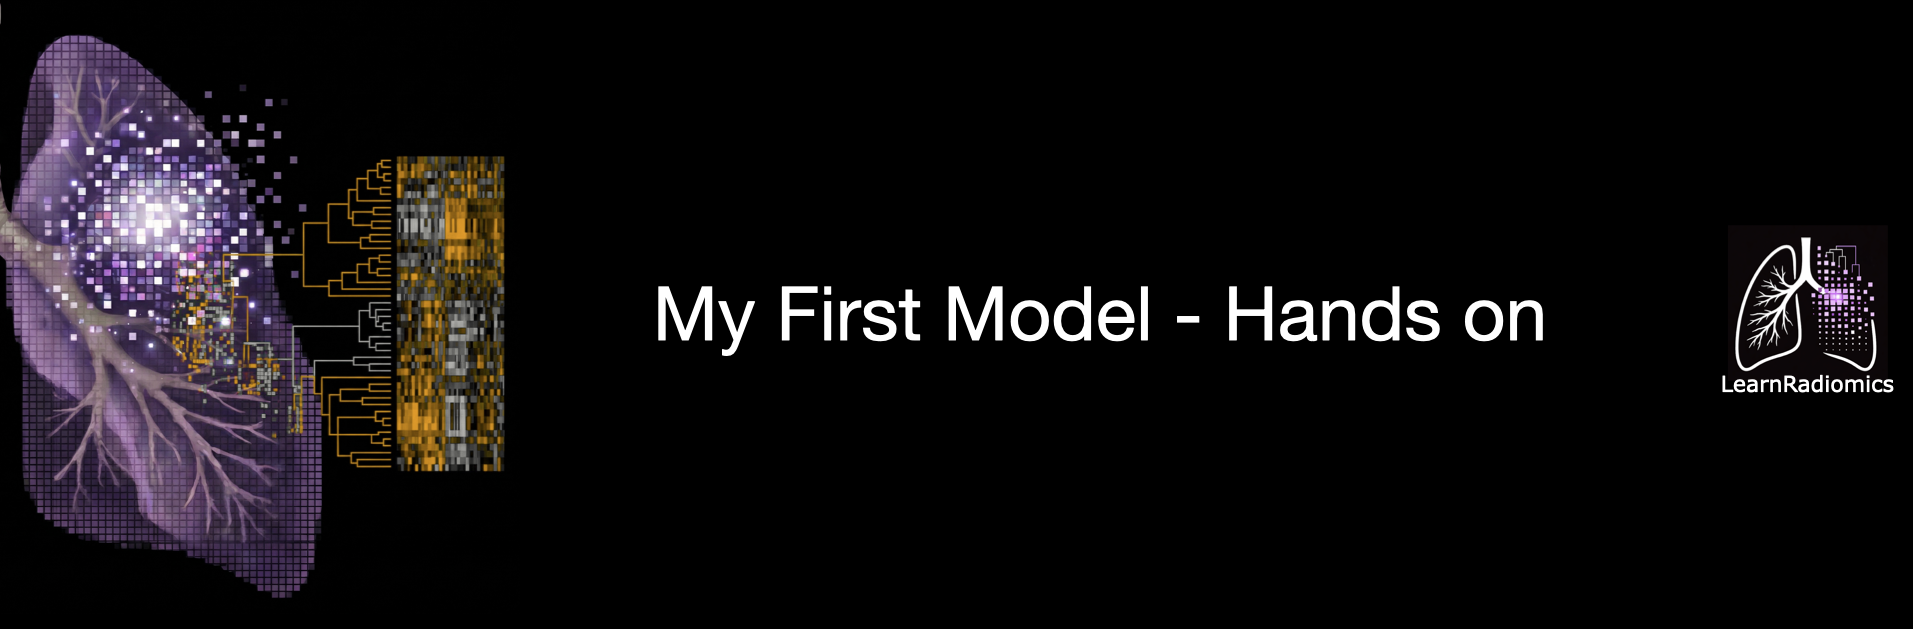

In [ ]:
## Herramientas generales
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

## Construcción de modelos
import tensorflow as tf
from keras import backend as K
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten, Dropout, Input,concatenate, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.datasets import mnist

import warnings
warnings.filterwarnings('ignore')

In [ ]:
## carga de datos MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

In [ ]:
## Visualización de MNIST
ROWS = 5
fig, axes1 = plt.subplots(ROWS,ROWS,figsize=(10,10))
for j in range(ROWS):
    for k in range(ROWS):
        i = np.random.randint(0, X_train.shape[0])
        axes1[j][k].set_axis_off()
        axes1[j][k].imshow(X_train[i,:,:], cmap='gray_r')
        axes1[j][k].set_title("number: {}".format(y_train[i]), size=8)


In [ ]:
index = 8

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Intensity Values')
ax1.hist(X_train[index].flatten(), bins=5, color='mediumorchid', edgecolor='black')
ax2.imshow(X_train[index,:,:], cmap='gray_r')

plt.show()

In [ ]:
num_classes = 10

## Preprocesamiento de datos MNIST
X_train = (X_train/255).astype('float32')
X_test = (X_test/255).astype('float32')

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("X_train dims:", X_train.shape)
print("X_test dims:", X_test.shape)
## Ejemplos de etiquetas:
print("*"*60)
print("y_train original:", y_train[0:2])
print("y_train One-Hot-Encodded:", y_train_cat[0:2])

In [ ]:
## Modelo Convolucional
tf.keras.backend.clear_session()

model = Sequential()

## Primera capa: Input y primera convolución:
model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(X_train.shape[1:])))
model.add(MaxPooling2D((2, 2)))

## Segunda capa convolucional:
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout((0.15)))

## Aplanado del vector y clasificación:
model.add(GlobalAveragePooling2D())
model.add(Dense(32, activation='relu'))
model.add(Dropout((0.1)))
model.add(Dense(num_classes, activation='softmax'))

## Muestra resumen del modelo:
model.summary()

In [ ]:
EPOCHS = 20
BATCH_SIZE = 256
LR = 0.005

## Compilado y entrenamiento
model.compile(optimizer=Adam(learning_rate=LR), loss = 'categorical_crossentropy', metrics= ['accuracy'])

history = model.fit(X_train, y_train_cat, epochs= EPOCHS, verbose= 1, batch_size= BATCH_SIZE,
                validation_data=(X_test, y_test_cat), shuffle= True)


In [ ]:

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, accuracy, 'bo', label='Training accuracy', color='salmon')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy', color='dodgerblue')
plt.title('Training and validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss, 'bo', label='Training loss', color='salmon')
plt.plot(epochs, val_loss, 'b', label='Validation loss', color='dodgerblue')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
pred_scores = model.predict(X_test)
y_pred = np.where(pred_scores > 0.5, 1, 0)
print(classification_report(y_test_cat, y_pred))

In [ ]:
numero = np.random.randint(0, X_test.shape[0])
print('caso Test:', numero)

img = X_test[numero]
img_tensor = np.expand_dims(img, axis=0)

prediccion = model.predict(img_tensor)
print("Predicción:", np.argmax(prediccion))
print("Respuesta correcta:",np.argmax(y_test_cat[numero]) )
print(". " *3)

plt.figure(figsize=(4,4))
plt.imshow(img[:,:,0], cmap='Blues_r')
plt.title("Predicción: {}".format(np.argmax(prediccion)))
plt.show()